# **Assignment 2**
# **Solving 1D Poisson Equation with the Finite-Difference Method**
**Course:** Numerical Analysis For PDE's (WI3730TU)  
**Instructions:** Complete the mathematical derivations and fill in the missing code blocks marked with `# TODO`. Ensure your notebook passes a clean **Kernel -> Restart & Run All** check before submission.

## Boundary Value Problem Statement
Consider the following 1D Poisson boundary-value problem:
$$\quad -\frac{d^{2}u}{dx^{2}} = f(x), \quad x \in (0,3)$$
With the Dirichlet boundary conditions:
$$\quad u(0) = 1, \quad u(3) = 2$$
We test this system using two unique source functions:
1. $f_1(x) = 3x - 2$
2. $f_2(x) = x^2 + 3x - 2$

### **Question 1: Grid Generation & Source Function Visualization (1 p)**
Before analyzing the operator discretization matrix, generate the discrete uniform coordinates and verify your source profiles.

*Complete the code cell below to generate a uniform 1D mesh over the interval $[0,3]$ with $n=5$ sub-intervals. Compute the corresponding grid values for both $f_1(x)$ and $f_2(x)$, and plot them in a single formatted figure featuring a legend and $\LaTeX$ annotations.*

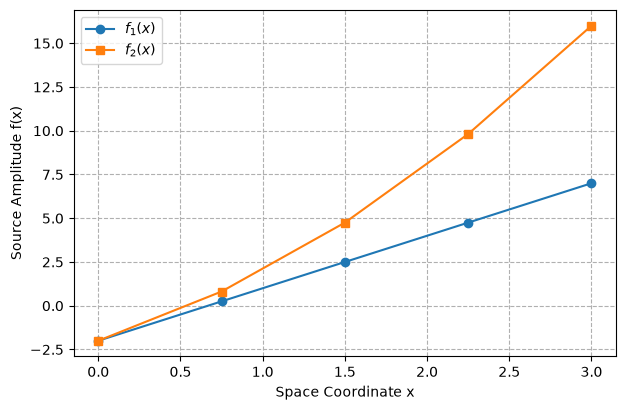

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# TODO: Step 1. Define the analytical source functions as python Callables
def f1(x):
    return 3 * x - 2

def f2(x):
    # YOUR CODE HERE: Implement the second source function
    return x**2 + 3*x - 2
# -------------------------------------------------------------------------

# Step 2. Construct the grid mesh array
n = 5
L = 3.0
x_mesh = np.linspace(0, L, n) # REPLACE THIS WITH np.linspace() for the actual grid

# Step 3. Generate your evaluation plot using your functions
plt.figure(figsize=(7, 4.5))
plt.plot(x_mesh, f1(x_mesh), '-o', label=r'$f_1(x)$')
plt.plot(x_mesh, f2(x_mesh), '-s', label=r'$f_2(x)$')
plt.xlabel('Space Coordinate x')
plt.ylabel('Source Amplitude f(x)')
plt.legend()
plt.grid(True, ls='--')
plt.show()

### **Question 2: Finite-Difference Approximation Theory (1 p)**
Write down the $\mathcal{O}(h^2)$ central finite-difference (FD) approximation formula for the negative second derivative operator ($-u''$), including the explicit Lagrangian remainder (truncation error) term. 

Define what domain range the arbitrary coordinate value $\xi$ belongs to.

---
For an internal grid point $x_j$, the second derivative is approximated using the central finite-difference formula. Using Taylor expansions around $x_j$,

$$
u(x_j+h)
=
u(x_j)
+h u'(x_j)
+\frac{h^2}{2}u''(x_j)
+\frac{h^3}{6}u'''(x_j)
+\frac{h^4}{24}u^{(4)}(x_j)
+O(h^5),
$$

and

$$
u(x_j-h)
=
u(x_j)
-h u'(x_j)
+\frac{h^2}{2}u''(x_j)
-\frac{h^3}{6}u'''(x_j)
+\frac{h^4}{24}u^{(4)}(x_j)
-O(h^5).
$$

Adding these equations gives

$$
u(x_j+h)-2u(x_j)+u(x_j-h)
=
h^2u''(x_j)
+\frac{h^4}{12}u^{(4)}(x_j)
+O(h^6).
$$

Therefore,

$$
u''(x_j)
=
\frac{u_{j-1}-2u_j+u_{j+1}}{h^2}
-\frac{h^2}{12}u^{(4)}(x_j)
+O(h^4).
$$

Since the problem contains the negative second derivative,

$$

-u''(x_j)
=
\frac{-u_{j-1}+2u_j-u_{j+1}}{h^2}
+\frac{h^2}{12}u^{(4)}(x_j)
+O(h^4)

$$

So the Lagrangian truncation error term $\xi$ is $\frac{h^2 u^{(4)}}{12}$. Hence, the finite-difference approximation is

$$

-u''(x_j)
\approx
\frac{-u_{j-1}+2u_j-u_{j+1}}{h^2}

$$

with truncation error of order $O(h^2)$.




### **Question 3: Full System of Finite-Difference Equations (1 p)**
Assuming $n=5$, write down the complete system of $n+1 = 6$ finite-difference equations for the entire grid layout, explicitly including the boundary nodes $x_0$ and $x_5$. 

Provide the explicit equations for the source function $f_1(x)$ only.

---
The grid points are

$$

x_0=0,\quad x_1=0.6,\quad x_2=1.2,\quad x_3=1.8,\quad x_4=2.4,\quad x_5=3.

$$

The boundary values are $u_0=1$ and $u_5=2.$ Instead of eliminating the boundary values, we keep all six grid values as variables,

$$

\mathbf{u}

=

\begin{bmatrix}

u_0\\

u_1\\

u_2\\

u_3\\

u_4\\

u_5

\end{bmatrix}.

$$

Using the finite-difference approximation and $h=0.6$, so that $h^2=0.36$, the interior equations are

$$

-u_0+2u_1-u_2=0.36f(0.6),

$$

$$

-u_1+2u_2-u_3=0.36f(1.2),

$$

$$

-u_2+2u_3-u_4=0.36f(1.8),

$$

$$

-u_3+2u_4-u_5=0.36f(2.4).

$$

Together with the boundary conditions give the six-variable linear system

$$

\begin{bmatrix}

1&0&0&0&0&0\\

-1&2&-1&0&0&0\\

0&-1&2&-1&0&0\\

0&0&-1&2&-1&0\\

0&0&0&-1&2&-1\\

0&0&0&0&0&1

\end{bmatrix}

\begin{bmatrix}

u_0\\

u_1\\

u_2\\

u_3\\

u_4\\

u_5

\end{bmatrix}

=

\begin{bmatrix}

1\\

0.36f(0.6)\\

0.36f(1.2)\\

0.36f(1.8)\\

0.36f(2.4)\\

2

\end{bmatrix}.

$$

For $f_1(x)=3x-2$,

$$

f_1(0.6)=-0.2,\qquad

f_1(1.2)=1.6,\qquad

f_1(1.8)=3.4,\qquad

f_1(2.4)=5.2.

$$

Therefore,

$$

\begin{bmatrix}

1&0&0&0&0&0\\

-1&2&-1&0&0&0\\

0&-1&2&-1&0&0\\

0&0&-1&2&-1&0\\

0&0&0&-1&2&-1\\

0&0&0&0&0&1

\end{bmatrix}

\begin{bmatrix}

u_0\\

u_1\\

u_2\\

u_3\\

u_4\\

u_5

\end{bmatrix}

=

\begin{bmatrix}

1\\

-0.072\\

0.576\\

1.224\\

1.872\\

2

\end{bmatrix}.

$$

For $f_2(x)=x^2+3x-2$,

$$

f_2(0.6)=0.16,\qquad

f_2(1.2)=3.04,\qquad

f_2(1.8)=6.64,\qquad

f_2(2.4)=10.96.

$$

Therefore,

$$

\begin{bmatrix}

1&0&0&0&0&0\\

-1&2&-1&0&0&0\\

0&-1&2&-1&0&0\\

0&0&-1&2&-1&0\\

0&0&0&-1&2&-1\\

0&0&0&0&0&1

\end{bmatrix}

\begin{bmatrix}

u_0\\

u_1\\

u_2\\

u_3\\

u_4\\

u_5

\end{bmatrix}

=

\begin{bmatrix}

1\\

0.0576\\

1.0944\\

2.3904\\

3.9456\\

2

\end{bmatrix}.

$$


### **Question 4: Linear Algebraic System Derivation (1 p)**
Using the full system of equations from Question 3, mathematically eliminate the known Dirichlet values $u_0 = 1$ and $u_5 = 2$. 

Show how this elimination reduces the system to a compact linear algebraic problem $A\mathbf{u} = \mathbf{f}$, where $A \in \mathbb{R}^{4 \times 4}$.

---
From Question 3, the four interior finite-difference equations are

$$
\frac{-u_0+2u_1-u_2}{h^2}=f(x_1),
$$

$$
\frac{-u_1+2u_2-u_3}{h^2}=f(x_2),
$$

$$
\frac{-u_2+2u_3-u_4}{h^2}=f(x_3),
$$

$$
\frac{-u_3+2u_4-u_5}{h^2}=f(x_4).
$$

Using the boundary conditions

$$
u_0=1,\qquad u_5=2,
$$

and $h=0.6$, so that $h^2=0.36$, the equations become

$$
\frac{2u_1-u_2}{0.36}
=
f(x_1)+\frac{1}{0.36},
$$

$$
\frac{-u_1+2u_2-u_3}{0.36}
=
f(x_2),
$$

$$
\frac{-u_2+2u_3-u_4}{0.36}
=
f(x_3),
$$

$$
\frac{-u_3+2u_4}{0.36}
=
f(x_4)+\frac{2}{0.36}.
$$

With

$$
\mathbf{u}
=
\begin{bmatrix}
u_1\\
u_2\\
u_3\\
u_4
\end{bmatrix},
$$

the reduced system can be written as $A\mathbf{u}=\mathbf{f}$, where

$$
A=
\frac{1}{0.36}
\begin{bmatrix}
2&-1&0&0\\
-1&2&-1&0\\
0&-1&2&-1\\
0&0&-1&2
\end{bmatrix}.
$$

For $f_1(x)=3x-2$,

$$
\mathbf{f}_1=
\begin{bmatrix}
-0.2+\frac{1}{0.36}\\
1.6\\
3.4\\
5.2+\frac{2}{0.36}
\end{bmatrix}
=
\begin{bmatrix}
2.5778\\
1.6\\
3.4\\
10.7556
\end{bmatrix}.
$$

For $f_2(x)=x^2+3x-2$,

$$
\mathbf{f}_2=
\begin{bmatrix}
0.16+\frac{1}{0.36}\\
3.04\\
6.64\\
10.96+\frac{2}{0.36}
\end{bmatrix}
=
\begin{bmatrix}
2.9378\\
3.04\\
6.64\\
16.5156
\end{bmatrix}.
$$


### **Question 5(a): Mathematical Structure of the System Matrix (1 p)**
Before implementing the code, state the exact dimension of your internal system matrix $A$ as a function of the number of sub-intervals $n$. 

Write out the algebraic definitions for the entries of the main diagonal ($A_{i,i}$) and the sub/super-diagonals ($A_{i,i-1}$, $A_{i,i+1}$).

---
The matrix $A$ contains the $n-1$ interior unknowns, so its dimension is

$$
A\in\mathbb{R}^{(n-1)\times(n-1)}.
$$

With $h=L/n$, the matrix entries are

$$
A_{i,i}=\frac{2}{h^2},
$$

and the sub- and super-diagonal entries are

$$
A_{i,i-1}=A_{i,i+1}=-\frac{1}{h^2}.
$$

Therefore,

$$
A=\frac{1}{h^2}
\begin{bmatrix}
2 & -1 & 0 & \cdots & 0\\
-1 & 2 & -1 & \ddots & \vdots\\
0 & -1 & 2 & \ddots & 0\\
\vdots & \ddots & \ddots & \ddots & -1\\
0 & \cdots & 0 & -1 & 2
\end{bmatrix}.
$$


### **Question 5(b): Dense Matrix Assembly Function (2 p)**

*Complete the function below to assemble a dense system matrix representing the negative second derivative operator under Dirichlet conditions.*


In [12]:
def assemble_system_matrix(n, L=3.0):
    """
    Constructs the dense tridiagonal FDM matrix A.
    Inputs:
        n : Number of sub-intervals
        L : Physical domain length
    Outputs:
        A : Dense 2D numpy array of size (n-1) x (n-1)
    """
    h = L / n
    
    main_diag = 2 * np.ones(n - 1)
    off_diag = -1 * np.ones(n - 2)

    A = (
    np.diag(main_diag)
    + np.diag(off_diag, 1)
    + np.diag(off_diag, -1)) / h**2
    # -------------------------------------------------------------------------
    return A

# Quick local test to verify structure for n=5
A_test = assemble_system_matrix(n=5)
print("Assembled Matrix A (n=5):\n", A_test)


Assembled Matrix A (n=5):
 [[ 5.55555556 -2.77777778  0.          0.        ]
 [-2.77777778  5.55555556 -2.77777778  0.        ]
 [ 0.         -2.77777778  5.55555556 -2.77777778]
 [ 0.          0.         -2.77777778  5.55555556]]


### **Question 6(a): Sizing of the Reduced Right-Hand-Side Vectors (1 p)**
For an arbitrary number of sub-intervals $n$ and an overall grid size of $n+1$ nodes, what is the exact vector size of your interior right-hand-side arrays $\mathbf{f}_1$ and $\mathbf{f}_2$ after boundary elimination? 

State explicitly which nodes (from $x_0$ to $x_n$) are used to evaluate the source function terms inside this reduced system and how the right-hand side vectors are modified after boundary-value elimination.

---
After eliminating the two boundary nodes $x_0$ and $x_n$, there are $n-1$ interior nodes. Therefore,

$$
\mathbf{f}_1,\mathbf{f}_2\in\mathbb{R}^{n-1}.
$$

The source functions are evaluated at the interior nodes

$$
x_1,x_2,\ldots,x_{n-1}.
$$

The boundary values are included in the first and last entries of the reduced right-hand side:

$$
\mathbf{f}=
\begin{bmatrix}
f(x_1)+\frac{u_0}{h^2}\\
f(x_2)\\
\vdots\\
f(x_{n-2})\\
f(x_{n-1})+\frac{u_n}{h^2}
\end{bmatrix}.
$$

### **Question 6(b): Right-Hand-Side Assembly Function (2 p)**

**Your task:** complete the function below to dynamically construct the modified RHS vectors for both $f_1(x)$ and $f_2(x)$ using the eliminated Dirichlet boundary values.

----

*Complete the function below to construct a single, modified RHS vector by passing your spatial grid array and your target function handle.*

In [13]:
def assemble_rhs_vector(x_mesh, f_func, u_left=1.0, u_right=2.0):
    """=
    Constructs a generic, reduced right-hand side vector.
    Inputs:
        x_mesh   : The FULL 1D grid coordinate array (including boundaries)
        f_func  : A python function handle/callable evaluating f(x)
        u_left : Value for Dirichlet boundary conditions u(0)
        u_right : Value for Dirichlet boundary conditions u(L)
    Outputs:
        f_rhs   : Modified RHS vector applied with BC adjustments, length (len(xgrid) - 2)
    """
    n = len(x_mesh) - 1
    L = x_mesh[-1] - x_mesh[0]
    h = L / n
    
    # -------------------------------------------------------------------------
    # TODO: Step 1. Extract the interior coordinates from your passed grid array
    x_interior = x_mesh[1:-1]  # REPLACE THIS WITH YOUR INTERIOR MESH STRIDE
    
    # Evaluate the source function dynamically via its functional handle
    f_base = f_func(x_interior)
    
    # TODO: Step 2. Apply your mathematically eliminated boundary modifications
    f_rhs = f_base.copy()
    f_rhs[0] += u_left / h**2
    f_rhs[-1] += u_right / h**2
    
    # YOUR BOUNDARY SHIFTING CODE HERE (Modify the first and last entries)
    
    # -------------------------------------------------------------------------
    return f_rhs

# Quick local test for sample grid [0,1,2,3,4] 
rhs1 = assemble_rhs_vector(x_mesh = np.array([0,1,2,3,4]), f_func=f1, u_left=1.0, u_right=2.0)
rhs2 = assemble_rhs_vector(x_mesh = np.array([0,1,2,3,4]), f_func=f2, u_left=1.0, u_right=2.0)
print('Assembled rhs vector for f1 source:\n',rhs1)
print('Assembled rhs vector for f2 source:\n',rhs2)


Assembled rhs vector for f1 source:
 [2 4 9]
Assembled rhs vector for f2 source:
 [ 3  8 18]


### **Question 7: Numerical Solver Loop (2 p)**
Now that you have built modules for constructing your system matrix and RHS vetors, write a script execution block to solve the system.

**Your Task:** Complete the code cell below to generate a uniform grid over $x \in [0,3]$ for $n=5$. Call your `assemble_system_matrix` and `assemble_rhs_vector` functions to construct the linear algebra structures, apply `scipy.linalg.solve()`, and pad the boundary conditions ($u(0)=1, u(3)=2$) onto your final internal solution vectors.

In [14]:
import scipy.linalg as la

def solve_poisson_problem(n, L=3.0, u_left=1.0, u_right=2.0):
    # -------------------------------------------------------------------------
    # TODO: Step 1. Generate the true uniform grid array matching Question 1
    x_full = np.linspace(0, L, n + 1) # REPLACE THIS WITH YOUR np.linspace STRIDE
    
    # TODO: Step 2. Build system matrices by passing variables into your modules
    A_matrix = assemble_system_matrix(n, L)          # REPLACE: call assemble_system_matrix
    rhs_f1 = assemble_rhs_vector(x_full, f1, u_left, u_right)
    rhs_f2 = assemble_rhs_vector(x_full, f2, u_left, u_right)        
    # -------------------------------------------------------------------------
    
    # Direct solution execution
    u1_int = la.solve(A_matrix, rhs_f1)
    u2_int = la.solve(A_matrix, rhs_f2)
    
    # TODO: Step 3. Reconstruct full numerical solution fields including boundaries
    u1_solution = np.concatenate(([u_left], u1_int, [u_right]))
    u2_solution = np.concatenate(([u_left], u2_int, [u_right]))
    
    return x_full, u1_solution, u2_solution

# Run solution check for baseline parameter n=5
x_mesh, u1_num, u2_num = solve_poisson_problem(n=5)
print("Numerical solver execution completed.")

Numerical solver execution completed.


### **Question 8: Analytical Comparison and Solution Visualization (1 p)**
Verify your numerical finite difference configurations by overlaying them visually with the true exact solutions.

**Your Task:** Calculate the anlytical solutions $u_1^{ex}$ and $u_2^{ex}$ of the boundary value problem for both source functions. Complete the plotting configuration below using the numerical vectors you computed in Question 7 for $n=5$ and the analytical exact values on your mesh nodes and generate a formatted comparison figure.

--- 
**Plot Guidelines:** Use solid lines for your exact solutions ($u_1^{ex}, u_2^{ex}$), and dashed lines with distinctive circular/square point markers for your discrete approximations ($u_1, u_2$). Include full grid markers, axis labels, and LaTeX legends.

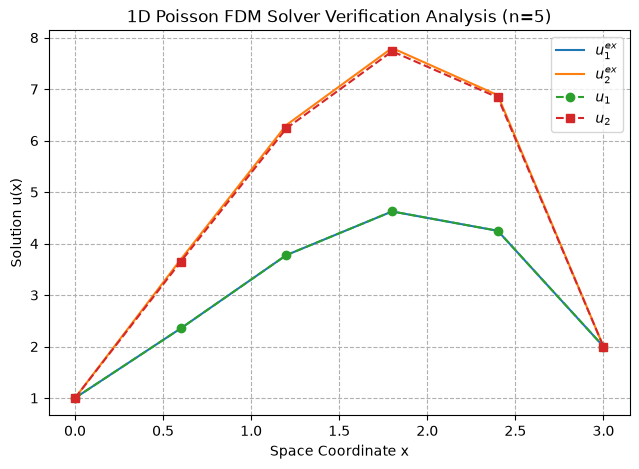

In [15]:
# TODO: Step 1. Code exact analytical solution formulas for comparison mapping
# Note: Account for non-homogeneous boundaries u(0)=1 and u(3)=2
u1_exact = -0.5*x_mesh**3 + x_mesh**2 + (11/6)*x_mesh + 1

u2_exact = (
    -(1/12)*x_mesh**4
    - 0.5*x_mesh**3
    + x_mesh**2
    + (49/12)*x_mesh
    + 1
)


# Step 2: Overlay plot
plt.figure(figsize=(7.5, 5))

# Exact solutions
plt.plot(x_mesh, u1_exact, '-', label=r'$u_1^{ex}$')
plt.plot(x_mesh, u2_exact, '-', label=r'$u_2^{ex}$')

# Numerical solutions
plt.plot(x_mesh, u1_num, '--o', label=r'$u_1$')
plt.plot(x_mesh, u2_num, '--s', label=r'$u_2$')

plt.xlabel('Space Coordinate x')
plt.ylabel('Solution u(x)')
plt.title('1D Poisson FDM Solver Verification Analysis (n=5)')
plt.grid(True, ls='--')
plt.legend()
plt.show()

### **Question 9: Continuous vs. Discrete Eigenvalue Analysis (2 p)**
Let the analytical eigenvalues of the continuous negative second-derivative operator $-d^2/dx^2$ be denoted as $\tilde{\lambda}_i$, and the analytical eigenvalues of the corresponding discrete FDM matrix $A$ as $\lambda_i$.

**Your Task:** Using your `assemble_system_matrix` function for $n=5$, numerically calculate the matrix eigenvalues using `np.linalg.eig()`. Sort them from smallest to largest and present them side-by-side with the analytical formulas inside the LaTeX table cell below.

--- 
*Double-click this cell to modify and fill out the values in this $\LaTeX$ Table:* 

| $i$ | Continuous Operator $\tilde{\lambda}_i$ | Discrete Analytical $\lambda_i$ | Numerical Array `np.linalg.eig()` |
|---|---:|---:|---:|
| 1 | $1.0966$ | $1.0610$ | $1.0610$ |
| 2 | $4.3865$ | $3.8388$ | $3.8388$ |
| 3 | $9.8696$ | $7.2723$ | $7.2723$ |
| 4 | $17.5460$ | $10.0501$ | $10.0501$ |

In [18]:
# TODO: Step 1. Assemble the test matrix A for n=5
A_eigen = assemble_system_matrix(n=5)

# TODO: Step 2. Compute and extract the numerical eigenvalues
raw_evals = np.sort(np.linalg.eig(A_eigen)[0])
# Hint: np.linalg.eig returns an unsorted tuple (values, vectors). Extract and sort the values!

print("Your computed and sorted numerical eigenvalues:\n", raw_evals)

Your computed and sorted numerical eigenvalues:
 [ 1.0610167   3.83879448  7.27231664 10.05009441]


### **Question 10(a): Global Error Log-Log Convergence Plot (1 p)**
We want to observe how the overall solution error behaves asymptotically as our discrete uniform mesh grid gets progressively finer.

**Your Task:** Run the convergence nested loop cell below. It will execute your solver dynamically across an array of increasing intervals ($n = [5, 10, 20, 40, 80, 160, 320, 640]$) and plot the Root-Mean-Squared-Errors (RMSE) using a log-log scaling perspective.


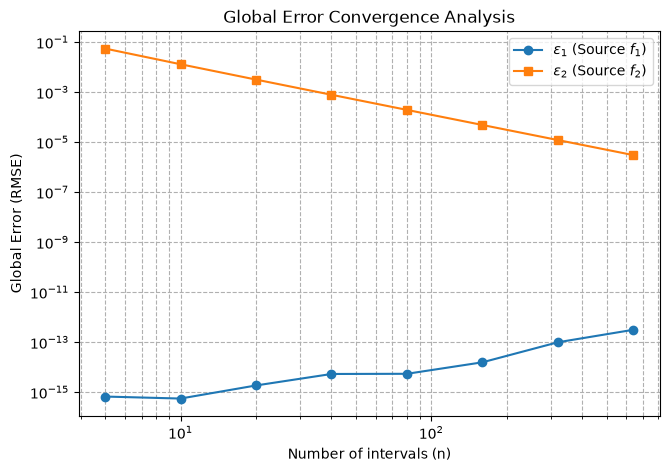

In [20]:
intervals = [5, 10, 20, 40, 80, 160, 320, 640]
errors_f1 = []
errors_f2 = []

for n in intervals:
    # Run your executive modular solver function
    x_mesh, u1_n, u2_n = solve_poisson_problem(n)
    
    # Analytical true benchmarks mapping non-homogeneous boundaries
    u1_exact = (-0.5 * x_mesh**3+ x_mesh**2+ (11/6) * x_mesh+ 1)
    u2_exact = (-(1/12) * x_mesh**4- 0.5 * x_mesh**3+ x_mesh**2+ (49/12) * x_mesh+ 1)

    
    # Calculate Root Mean Squared Errors on interior nodes
    rmse_1 = np.sqrt(np.mean((u1_n[1:-1] - u1_exact[1:-1])**2))
    rmse_2 = np.sqrt(np.mean((u2_n[1:-1] - u2_exact[1:-1])**2))
    
    errors_f1.append(rmse_1)
    errors_f2.append(rmse_2)

# Generate the dynamic log-log error tracking plot
plt.figure(figsize=(7.5, 5))
plt.loglog(intervals, errors_f1, '-o', label=r'$\epsilon_1$ (Source $f_1$)')
plt.loglog(intervals, errors_f2, '-s', label=r'$\epsilon_2$ (Source $f_2$)')
plt.xlabel('Number of intervals (n)')
plt.ylabel('Global Error (RMSE)')
plt.title('Global Error Convergence Analysis')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

### **Question 10(b): Analysis of Convergence Bahavior (2 p)**

Once the graph renders, write a comprehensive analytical report explaining:

1. Why the global error $\epsilon_{1}$ (source $f_{1}$) and the global error $\epsilon_{2}$ (source $f_{2}$) behave differently.
2. Use the global error $\epsilon_{2}$ (source $f_{2}$) to prove that your scheme operates at a true quadratic rate of convergence.

---
The different convergence behaviour of $\epsilon_1$ and $\epsilon_2$ follows from the truncation error of the central finite-difference approximation. For the second derivative, the leading truncation-error term is proportional to

$$
h^2u^{(4)}(\xi).
$$

For the first source function, the exact solution is

$$
u_1(x)
=
-\frac{1}{2}x^3+x^2+\frac{11}{6}x+1.
$$

Since $u_1$ is cubic,

$$
u_1^{(4)}(x)=0.
$$

Therefore, the leading truncation-error term is exactly zero. In fact, the central finite-difference approximation reproduces the second derivative of this cubic solution exactly at the grid points. Consequently, $\epsilon_1$ is theoretically zero and the small non-zero values observed numerically are caused only by floating-point round-off errors.

For the second source function,

$$
u_2(x)
=
-\frac{1}{12}x^4-\frac{1}{2}x^3+x^2+\frac{49}{12}x+1.
$$

This solution is quartic and therefore

$$
u_2^{(4)}(x)=-2\neq0.
$$

Hence the leading truncation-error term does not vanish, and the numerical error behaves as

$$
\epsilon_2=O(h^2).
$$

Since

$$
h=\frac{L}{n},
$$

doubling the number of intervals halves the grid spacing. Therefore,

$$
\epsilon_2(2n)
\approx
\left(\frac{h}{2}\right)^2
=
\frac{1}{4}h^2,
$$

so the error should decrease by approximately a factor of four whenever $n$ is doubled.

The observed order of convergence can be calculated from two consecutive errors as

$$
p=
\frac{\log\left(\epsilon_2(n)/\epsilon_2(2n)\right)}
{\log 2}.
$$

For a second-order finite-difference scheme,

$$
p\approx2.
$$

Thus, the decreasing $\epsilon_2$ values confirm that the method has a quadratic convergence rate. On a log-log plot against the number of intervals $n$, this corresponds to an approximately straight line with slope $-2$, since $\epsilon_2\propto n^{-2}$.